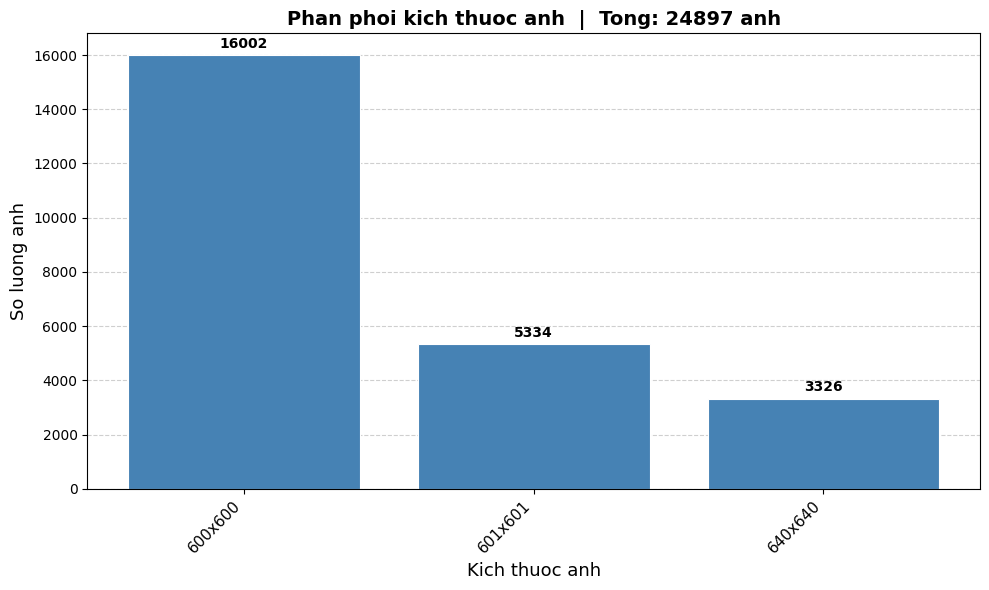

Da luu: D:\CS\DeepLearning\midterm\PCB_Defect_Dataset\plots\image_sizes_plot.png
Saved: D:\CS\DeepLearning\midterm\PCB_Defect_Dataset\plots\defect_image_count_bar.png
Saved: D:\CS\DeepLearning\midterm\PCB_Defect_Dataset\plots\bbox_size_scatter_by_class.png
Saved: D:\CS\DeepLearning\midterm\PCB_Defect_Dataset\plots\bbox_size_scatter_by_split.png
Saved: D:\CS\DeepLearning\midterm\PCB_Defect_Dataset\plots\bbox_hexbin_overall.png
Saved: D:\CS\DeepLearning\midterm\PCB_Defect_Dataset\plots\image_sizes_plot.png
Saved: D:\CS\DeepLearning\midterm\PCB_Defect_Dataset\dataset_info.json


In [2]:
import argparse
import json
import sys
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import DefaultDict, Dict, List, Sequence, Set, Tuple

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def read_class_names(classes_file: Path) -> List[str]:
    if not classes_file.exists():
        raise FileNotFoundError(f"Missing classes file: {classes_file}")
    return [line.strip() for line in classes_file.read_text(encoding="utf-8").splitlines() if line.strip()]


def collect_stats(
    dataset_root: Path, class_names: Sequence[str]
) -> Tuple[
    List[int],
    DefaultDict[int, List[Tuple[float, float]]],
    Dict[str, List[Tuple[float, float]]],
    Dict[str, int],
    Dict[str, int],
]:
    image_sets_by_class: DefaultDict[int, Set[str]] = defaultdict(set)
    bbox_points_by_class: DefaultDict[int, List[Tuple[float, float]]] = defaultdict(list)
    split_bbox_points: Dict[str, List[Tuple[float, float]]] = {"train": [], "val": [], "test": []}
    split_label_file_counts: Dict[str, int] = {"train": 0, "val": 0, "test": 0}
    split_bbox_counts: Dict[str, int] = {"train": 0, "val": 0, "test": 0}

    for split in ("train", "val", "test"):
        labels_dir = dataset_root / split / "labels_txt"
        if not labels_dir.exists():
            continue

        for label_path in labels_dir.glob("*.txt"):
            split_label_file_counts[split] += 1
            image_key = f"{split}/{label_path.stem}"
            lines = label_path.read_text(encoding="utf-8").splitlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                class_id = int(float(parts[0]))
                if class_id < 0 or class_id >= len(class_names):
                    continue

                bw = float(parts[3])
                bh = float(parts[4])

                image_sets_by_class[class_id].add(image_key)
                bbox_points_by_class[class_id].append((bw, bh))
                split_bbox_points[split].append((bw, bh))
                split_bbox_counts[split] += 1

    image_count_per_class = [len(image_sets_by_class[idx]) for idx in range(len(class_names))]
    return (
        image_count_per_class,
        bbox_points_by_class,
        split_bbox_points,
        split_label_file_counts,
        split_bbox_counts,
    )


def count_images_in_split(dataset_root: Path, split: str) -> int:
    images_dir = dataset_root / split / "images"
    if not images_dir.exists():
        return 0

    image_suffixes = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    return sum(1 for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_suffixes)


def plot_image_count_bar(class_names: Sequence[str], image_counts: Sequence[int], out_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(class_names, image_counts)

    ax.set_title("So luong anh moi loi")
    ax.set_xlabel("Loai loi")
    ax.set_ylabel("So anh")
    ax.tick_params(axis="x", rotation=25)

    for bar, value in zip(bars, image_counts):
        ax.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha="center", va="bottom", fontsize=8)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def plot_bbox_scatter(
    class_names: Sequence[str],
    bbox_points_by_class: DefaultDict[int, List[Tuple[float, float]]],
    out_path: Path,
    max_points_per_class: int = 5000,
) -> None:
    fig, ax = plt.subplots(figsize=(9, 7))

    for class_id, class_name in enumerate(class_names):
        points = bbox_points_by_class.get(class_id, [])
        if not points:
            continue

        sampled = points[:max_points_per_class]
        xs = [p[0] for p in sampled]
        ys = [p[1] for p in sampled]
        ax.scatter(xs, ys, s=7, alpha=0.45, label=f"{class_name} (n={len(points)})")

    ax.set_title("Phan tan kich thuoc bbox (YOLO normalized)")
    ax.set_xlabel("bbox width")
    ax.set_ylabel("bbox height")
    ax.set_xlim(0.0, 0.5)
    ax.set_ylim(0.0, 0.5)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def plot_bbox_scatter_by_split(split_bbox_points: Dict[str, List[Tuple[float, float]]], out_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(9, 7))

    split_colors = {
        "train": "#1f77b4",
        "val": "#ff7f0e",
        "test": "#2ca02c",
    }

    for split in ("train", "val", "test"):
        points = split_bbox_points.get(split, [])
        if not points:
            continue

        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        ax.scatter(xs, ys, s=7, alpha=0.35, label=f"{split} (n={len(points)})", c=split_colors[split])

    ax.set_title("Phan tan kich thuoc bbox theo split (YOLO normalized)")
    ax.set_xlabel("bbox width")
    ax.set_ylabel("bbox height")
    ax.set_xlim(0.0, 0.5)
    ax.set_ylim(0.0, 0.5)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=9)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def plot_bbox_hexbin_overall(split_bbox_points: Dict[str, List[Tuple[float, float]]], out_path: Path) -> None:
    points = split_bbox_points["train"] + split_bbox_points["val"] + split_bbox_points["test"]
    if not points:
        return

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    fig, ax = plt.subplots(figsize=(9, 7))
    hb = ax.hexbin(xs, ys, gridsize=60, mincnt=1, cmap="viridis")
    cbar = fig.colorbar(hb, ax=ax)
    cbar.set_label("So luong bbox trong o")

    ax.set_title("Mat do kich thuoc bbox tong the (Hexbin)")
    ax.set_xlabel("bbox width")
    ax.set_ylabel("bbox height")
    ax.set_xlim(0.0, 0.5)
    ax.set_ylim(0.0, 0.5)
    ax.grid(alpha=0.2)

    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)


def plot_image_sizes_from_folder(image_dir: Path | str = ".", out_path: Path | str = "plots/image_sizes_plot.png") -> None:
    sizes = []
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

    image_root = Path(image_dir)
    for path in image_root.rglob("*"):
        if path.suffix.lower() in extensions and path.is_file():
            try:
                with Image.open(path) as img:
                    w, h = img.size
                    sizes.append(f"{w}x{h}")
            except Exception:
                pass

    if not sizes:
        print("Khong tim thay anh!")
        return

    size_counts = Counter(sizes)
    sorted_sizes = sorted(size_counts.items(), key=lambda x: -x[1])
    filtered_sizes = [(size, count) for size, count in sorted_sizes if count >= 50]
    if not filtered_sizes:
        print("Khong co kich thuoc nao co it nhat 50 anh!")
        return

    labels = [size for size, _ in filtered_sizes]
    counts = [count for _, count in filtered_sizes]

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.8), 6))
    x = np.arange(len(labels))
    bars = ax.bar(x, counts, color="steelblue", edgecolor="white", linewidth=0.8)

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            str(count),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.set_xlabel("Kich thuoc anh", fontsize=13)
    ax.set_ylabel("So luong anh", fontsize=13)
    ax.set_title(f"Phan phoi kich thuoc anh  |  Tong: {len(sizes)} anh", fontsize=14, fontweight="bold")
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    output_path = Path(out_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Da luu: {output_path}")


def summarize_bbox(points: Sequence[Tuple[float, float]]) -> Dict[str, float | int | None]:
    if not points:
        return {
            "count": 0,
            "width_min": None,
            "width_max": None,
            "width_mean": None,
            "height_min": None,
            "height_max": None,
            "height_mean": None,
            "area_min": None,
            "area_max": None,
            "area_mean": None,
        }

    widths = [p[0] for p in points]
    heights = [p[1] for p in points]
    areas = [w * h for w, h in points]

    return {
        "count": len(points),
        "width_min": min(widths),
        "width_max": max(widths),
        "width_mean": sum(widths) / len(widths),
        "height_min": min(heights),
        "height_max": max(heights),
        "height_mean": sum(heights) / len(heights),
        "area_min": min(areas),
        "area_max": max(areas),
        "area_mean": sum(areas) / len(areas),
    }


def write_dataset_info(
    dataset_root: Path,
    class_names: Sequence[str],
    image_counts: Sequence[int],
    bbox_points_by_class: DefaultDict[int, List[Tuple[float, float]]],
    split_bbox_points: Dict[str, List[Tuple[float, float]]],
    split_label_file_counts: Dict[str, int],
    split_bbox_counts: Dict[str, int],
    info_out_path: Path,
) -> None:
    split_image_counts = {split: count_images_in_split(dataset_root, split) for split in ("train", "val", "test")}

    dataset_info = {
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "dataset_root": str(dataset_root),
        "classes": list(class_names),
        "split_image_counts": split_image_counts,
        "split_label_file_counts": split_label_file_counts,
        "split_bbox_counts": split_bbox_counts,
        "total_images": sum(split_image_counts.values()),
        "total_labels": sum(split_bbox_counts.values()),
        "image_count_per_class": {
            class_names[class_id]: image_counts[class_id] for class_id in range(len(class_names))
        },
        "bbox_summary_overall": summarize_bbox(
            split_bbox_points["train"] + split_bbox_points["val"] + split_bbox_points["test"]
        ),
        "bbox_summary_by_split": {
            split: summarize_bbox(split_bbox_points[split]) for split in ("train", "val", "test")
        },
        "bbox_summary_by_class": {
            class_names[class_id]: summarize_bbox(bbox_points_by_class.get(class_id, []))
            for class_id in range(len(class_names))
        },
    }

    info_out_path.write_text(json.dumps(dataset_info, indent=2, ensure_ascii=False), encoding="utf-8")


def get_default_dataset_root() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parents[1]

    cwd = Path.cwd().resolve()
    if (cwd / "classes.txt").exists():
        return cwd
    if (cwd.parent / "classes.txt").exists():
        return cwd.parent
    return cwd


def main() -> None:
    parser = argparse.ArgumentParser(description="Ve bieu do thong ke loi PCB tu nhan YOLO")
    parser.add_argument(
        "--dataset-root",
        type=Path,
        default=get_default_dataset_root(),
        help="Duong dan root cua dataset",
    )
    parser.add_argument(
        "--out-dir",
        type=Path,
        default=None,
        help="Thu muc luu anh bieu do (mac dinh: <dataset-root>/plots)",
    )
    parser.add_argument(
        "--info-out",
        type=Path,
        default=None,
        help="File JSON thong tin dataset (mac dinh: <dataset-root>/dataset_info.json)",
    )

    if "ipykernel" in sys.modules:
        args, _ = parser.parse_known_args()
    else:
        args = parser.parse_args()

    dataset_root = args.dataset_root.resolve()
    out_dir = args.out_dir.resolve() if args.out_dir else dataset_root / "plots"
    info_out_path = args.info_out.resolve() if args.info_out else dataset_root / "dataset_info.json"
    out_dir.mkdir(parents=True, exist_ok=True)

    class_names = read_class_names(dataset_root / "classes.txt")
    (
        image_counts,
        bbox_points_by_class,
        split_bbox_points,
        split_label_file_counts,
        split_bbox_counts,
    ) = collect_stats(dataset_root, class_names)

    bar_path = out_dir / "defect_image_count_bar.png"
    scatter_class_path = out_dir / "bbox_size_scatter_by_class.png"
    scatter_split_path = out_dir / "bbox_size_scatter_by_split.png"
    hexbin_overall_path = out_dir / "bbox_hexbin_overall.png"
    image_size_path = out_dir / "image_sizes_plot.png"

    plot_image_count_bar(class_names, image_counts, bar_path)
    plot_bbox_scatter(class_names, bbox_points_by_class, scatter_class_path)
    plot_bbox_scatter_by_split(split_bbox_points, scatter_split_path)
    plot_bbox_hexbin_overall(split_bbox_points, hexbin_overall_path)
    plot_image_sizes_from_folder(dataset_root, image_size_path)
    write_dataset_info(
        dataset_root=dataset_root,
        class_names=class_names,
        image_counts=image_counts,
        bbox_points_by_class=bbox_points_by_class,
        split_bbox_points=split_bbox_points,
        split_label_file_counts=split_label_file_counts,
        split_bbox_counts=split_bbox_counts,
        info_out_path=info_out_path,
    )

    print(f"Saved: {bar_path}")
    print(f"Saved: {scatter_class_path}")
    print(f"Saved: {scatter_split_path}")
    print(f"Saved: {hexbin_overall_path}")
    print(f"Saved: {image_size_path}")
    print(f"Saved: {info_out_path}")


if __name__ == "__main__":
    main()